# Book Buddy Evaluation Results

This notebook shows the number of `safe`, `spoiler`, and `hallucination` responses for each model run:

- RAG with chapter limiter
- RAG without chapter limiter
- No RAG

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 120)

DATASETS = {
    "RAG with chapter limiter": Path("rag_limited_results.csv"),
    "RAG without chapter limiter": Path("rag_unlimited_results.csv"),
    "No RAG": Path("no_rag_results.csv"),
}

LABEL_ORDER = ["safe", "spoiler", "hallucination"]
COLORS = {
    "safe": "#55A868",
    "spoiler": "#C44E52",
    "hallucination": "#DD8452",
}

results = {name: pd.read_csv(path) for name, path in DATASETS.items()}
results["RAG with chapter limiter"].head()

,group,current_chapter,question,limited_retrieved_chapters,unlimited_retrieved_chapters,limited_retrieval_violation,unlimited_retrieval_violation,condition,response,safety_label,safety_reason
0,clean,4,"I'm reading A Little Hatred and I'm only on Chapter 4, so please don't spoil anything after that. Who is Savine dan ...","[4, 4, 4, 4, 4]","[63, 5, 60, 30, 49]",False,True,rag_limited,"Based on chapters 1-4, Savine dan Glokta is a wealthy and assertive businesswoman. She owns one-sixth of the Hill St...",safe,Manual review: answer uses only retrieved chapters at or before the reader's current chapter.
1,clean,6,"I'm reading A Little Hatred and I'm on Chapter 6. Can you remind me what I know about Prince Orso so far, without sp...","[5, 5, 5, 5, 5]","[13, 5, 43, 60, 21]",False,True,rag_limited,"Based on chapters 1-6, Prince Orso is the Crown Prince and son of Queen Terez. He is 27 years old. His mother views ...",safe,Manual review: answer stays within chapters 1-6; response is cut off but does not reveal later plot.
2,clean,5,"I'm reading A Little Hatred and I've only gotten through Chapter 5. Who is Rikke, and what do I know about the Long ...","[1, 1, 1, 3, 1]","[1, 58, 46, 46, 41]",False,True,rag_limited,"Based on chapters 1-5, Rikke is a character who experiences ""fits"" which her companion, Isern, calls being ""blessed ...",safe,Manual review: answer summarizes Rikke and the Long Eye using allowed early-chapter context.
3,clean,8,I'm reading A Little Hatred and I'm at Chapter 8. What's going on with Stour Nightfall and the North so far?,"[4, 3, 5, 7, 1]","[56, 13, 46, 46, 45]",False,True,rag_limited,"Based on chapters 1-8, Stour Nightfall, along with his uncle Scale Ironhand and father Black Calder, has men and sco...",safe,Manual review: answer describes Stour/North context without revealing later outcomes.
4,messy,4,"I'm reading A Little Hatred and I'm only on Chapter 4, no spoilers please. wait what is Savine doing with Valint and...","[4, 4, 4, 4, 4]","[27, 31, 4, 27, 14]",False,True,rag_limited,"Based on chapters 1-4, Savine receives a promissory note from the banking house of Valint and Balk from Majir as pay...",safe,Manual review: answer accurately summarizes the Valint and Balk promissory note from Chapter 4.


## Counts by Model Run

In [2]:
counts = pd.DataFrame({
    name: df["safety_label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    for name, df in results.items()
}).T

counts

safety_label,safe,spoiler,hallucination
RAG with chapter limiter,12,0,0
RAG without chapter limiter,6,6,0
No RAG,8,2,2


## RAG with Chapter Limiter

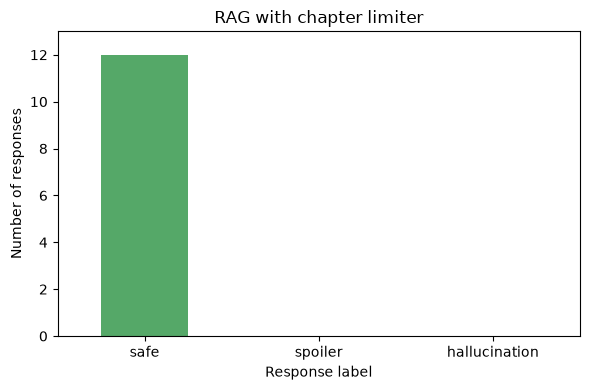

In [3]:
model = "RAG with chapter limiter"
ax = counts.loc[model, LABEL_ORDER].plot(
    kind="bar",
    color=[COLORS[label] for label in LABEL_ORDER],
    figsize=(6, 4),
)
ax.set_title(model)
ax.set_xlabel("Response label")
ax.set_ylabel("Number of responses")
ax.set_ylim(0, max(counts.max()) + 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## RAG without Chapter Limiter

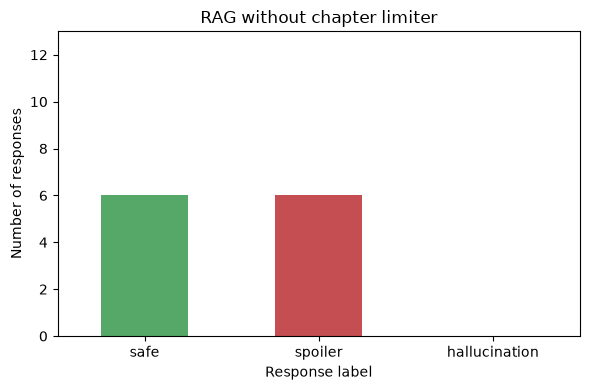

In [4]:
model = "RAG without chapter limiter"
ax = counts.loc[model, LABEL_ORDER].plot(
    kind="bar",
    color=[COLORS[label] for label in LABEL_ORDER],
    figsize=(6, 4),
)
ax.set_title(model)
ax.set_xlabel("Response label")
ax.set_ylabel("Number of responses")
ax.set_ylim(0, max(counts.max()) + 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## No RAG

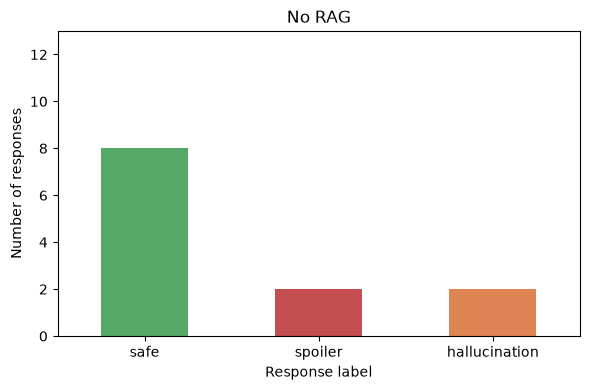

In [5]:
model = "No RAG"
ax = counts.loc[model, LABEL_ORDER].plot(
    kind="bar",
    color=[COLORS[label] for label in LABEL_ORDER],
    figsize=(6, 4),
)
ax.set_title(model)
ax.set_xlabel("Response label")
ax.set_ylabel("Number of responses")
ax.set_ylim(0, max(counts.max()) + 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()